In [13]:
import numpy as np
from matplotlib import pyplot as plt
!pip install pydicom
import pydicom
!pip install pymedphys
import pymedphys
import imageio.v3 as iio
from google.colab import files
import math
import scipy


from scipy.ndimage import affine_transform
import pydicom
!pip install SimpleITK
import SimpleITK as sitk
#ho preso spunto per il codice (soprattutto per la funzione "gamma") da questo sito: (vedi sezione "Calculate and Display Gamma")
#https://docs.pymedphys.com/en/latest/users/howto/gamma/from-dicom.html

In [14]:
#
#𝓡𝓲𝓶𝓸𝔃𝓲𝓸𝓷𝓮 𝓯𝓲𝓵𝓮 𝓿𝓮𝓬𝓬𝓱𝓲
!rm *.dcm
reference=files.upload();filenameMVCT = next(iter(reference));print(filenameMVCT)
evaluation=files.upload();filenamesMVCT = next(iter(evaluation));print(filenamesMVCT)
registration_file=files.upload();registration_file = next(iter(registration_file));


Saving RD.1.2.246.352.71.7.501772896434.1934831.20241212145308.dcm to RD.1.2.246.352.71.7.501772896434.1934831.20241212145308.dcm
RD.1.2.246.352.71.7.501772896434.1934831.20241212145308.dcm


Saving RD.1.2.246.352.71.7.501772896434.1934812.20241212143733.dcm to RD.1.2.246.352.71.7.501772896434.1934812.20241212143733.dcm
RD.1.2.246.352.71.7.501772896434.1934812.20241212143733.dcm


Saving RE.1.2.246.352.205.5104944736859573395.12085477317786888103.dcm to RE.1.2.246.352.205.5104944736859573395.12085477317786888103.dcm


In [20]:
reference_dicom=pydicom.dcmread(filenameMVCT);evaluation_dicom=pydicom.dcmread(filenamesMVCT);registration = pydicom.dcmread(registration_file)

#verificare se [0] oppure [1]
reg_seq = registration.RegistrationSequence[0];


matrix_reg_seq = reg_seq.MatrixRegistrationSequence[0];matrix_seq = matrix_reg_seq.MatrixSequence[0];matrix = matrix_seq.FrameOfReferenceTransformationMatrix
matrix_np = np.array(matrix).reshape(4, 4)

rows_dose_ref = reference_dicom.Rows;columns_dose_ref = reference_dicom.Columns;pixel_spacing_dose_ref = reference_dicom.PixelSpacing;image_position_dose_ref = reference_dicom.ImagePositionPatient
rows_dose_eval = evaluation_dicom.Rows;columns_dose_eval = evaluation_dicom.Columns;pixel_spacing_dose_eval = evaluation_dicom.PixelSpacing;image_position_dose_eval = evaluation_dicom.ImagePositionPatient

dose_reference=np.flip( (reference_dicom.pixel_array).reshape((len(reference_dicom.GridFrameOffsetVector)),(rows_dose_ref),(columns_dose_ref) )* reference_dicom.DoseGridScaling,axis=1)
dose_evaluation=np.flip( (evaluation_dicom.pixel_array).reshape((len(evaluation_dicom.GridFrameOffsetVector)),(rows_dose_eval),(columns_dose_eval) )* evaluation_dicom.DoseGridScaling,axis=1)
direction = np.eye(3);origin = image_position_dose_eval  # physical origin in mm
image_position_dose_eval = origin+np.array([matrix_np[0, 3], matrix_np[1, 3], matrix_np[2, 3]])#+origin #aggiunta traslazione dal file della registrazione

x_dose_ref = (((((np.arange(columns_dose_ref)*pixel_spacing_dose_ref[0]) + image_position_dose_ref[0]))))-pixel_spacing_dose_ref[0]
y_dose_ref = -((rows_dose_ref)-1)*pixel_spacing_dose_ref[1]+(np.arange(rows_dose_ref)*pixel_spacing_dose_ref[1]- image_position_dose_ref[1])-pixel_spacing_dose_ref[1]*2/2
z_dose_ref = np.array(reference_dicom.GridFrameOffsetVector) + image_position_dose_ref[2]-reference_dicom.GridFrameOffsetVector[1]/2
x_dose_eval = (((np.arange(columns_dose_eval)*pixel_spacing_dose_eval[0]) + image_position_dose_eval[0]))-pixel_spacing_dose_eval[0]
y_dose_eval = -((rows_dose_eval)-1)*pixel_spacing_dose_eval[1]+(np.arange(rows_dose_eval)*pixel_spacing_dose_eval[1]- image_position_dose_eval[1])-pixel_spacing_dose_eval[1]*2/2
z_dose_eval = np.array(evaluation_dicom.GridFrameOffsetVector) + image_position_dose_eval[2]-evaluation_dicom.GridFrameOffsetVector[1]/2

#print("posizione iniziale della griglia di dose della MVCT: "+str(reference.ImagePositionPatient))
print("Griglia MVCT da assi inizio: ",str([x_dose_ref[0],y_dose_ref[0],z_dose_ref[0]]))
print("griglia MVCT da assi fine: ",str([x_dose_ref[len(x_dose_ref)-1],y_dose_ref[len(y_dose_ref)-1],z_dose_ref[len(z_dose_ref)-1]]))
#print("fine griglia MVCT da assi: ",str([x_dose_ref[np.int16(x_dose_ref.shape)-1],y_dose_ref[np.int16(y_dose_ref.shape)-1],z_dose_ref[np.int16(z_dose_ref.shape)-1]]))
print("Griglia sMVCT da assi inizio: ",str([x_dose_eval[0],y_dose_eval[0],z_dose_eval[0]]))
print("griglia sMVCT da assi fine: ",str([x_dose_eval[len(x_dose_eval)-1],y_dose_eval[len(y_dose_eval)-1],z_dose_eval[len(z_dose_eval)-1]]))

# 𝓥𝓮𝓻𝓲𝓯𝓲𝓬𝓪 𝓽𝓻𝓪𝓼𝓵𝓪𝔃𝓲𝓸𝓷𝓮 𝓭𝓪𝓵 𝓯𝓲𝓵𝓮 𝓭𝓲𝓬𝓸𝓶
# se non va bene correggere registration.RegistrationSequence[1] --> [0] o viceversa
print("traslazione file dicom: ")
np.array([matrix_np[0, 3], matrix_np[1, 3], matrix_np[2, 3]])


Griglia MVCT da assi inizio:  [np.float64(-197.25), np.float64(-129.25), np.float64(-208.0)]
griglia MVCT da assi fine:  [np.float64(165.25), np.float64(140.75), np.float64(156.0)]
Griglia sMVCT da assi inizio:  [np.float64(-194.8111710168419), np.float64(-131.74171436497727), np.float64(-189.70677397651608)]
griglia sMVCT da assi fine:  [np.float64(170.1888289831581), np.float64(135.75828563502273), np.float64(160.29322602348392)]
traslazione file dicom: 


array([1.29733818, 3.62538686, 2.29322602])

In [21]:
from numba import njit

@njit(fastmath=True)
def trilinear_interpolation_jit(
    x_volume,
    y_volume,
    z_volume,
    volume,
    x_needed,
    y_needed,
    z_needed
):
    """
    Trilinear interpolation (from Wikipedia)

    :param x_volume: x points of the volume grid
    :type crack_type: list or numpy.ndarray
    :param y_volume: y points of the volume grid
    :type crack_type: list or numpy.ndarray
    :param x_volume: z points of the volume grid
    :type crack_type: list or numpy.ndarray
    :param volume:   volume
    :type crack_type: list or numpy.ndarray
    :param x_needed: desired x coordinate of volume
    :type crack_type: float
    :param y_needed: desired y coordinate of volume
    :type crack_type: float
    :param z_needed: desired z coordinate of volume
    :type crack_type: float

    :return volume_needed: desired value of the volume, i.e. volume(x_needed, y_needed, z_needed)
    :type volume_needed: float
    """

    # dimensinoal check
    assert np.shape(volume) == (
        len(x_volume), len(y_volume), len(z_volume)
    ), "Incompatible lengths"
    # check of the indices needed for the correct control volume definition
    i = np.searchsorted(x_volume, x_needed)
    j = np.searchsorted(y_volume, y_needed)
    k = np.searchsorted(z_volume, z_needed)
    # control volume definition
    control_volume_coordinates = np.array(
        [
            [
                x_volume[i - 1],
                y_volume[j - 1],
                z_volume[k - 1]
            ],
            [
                x_volume[i],
                y_volume[j],
                z_volume[k]
            ]
        ]
    )
    xd = (
        np.array([x_needed, y_needed, z_needed]) - control_volume_coordinates[0]
    ) / (
        control_volume_coordinates[1] - control_volume_coordinates[0]
    )
    # interpolation along x
    c2 = [[0., 0.], [0., 0.]]
    for m, n in [(0, 0), (0, 1), (1, 0), (1, 1)]:
        c2[m][n] = volume[i - 1][j - 1 + m][k - 1 + n] \
        * (1. - xd[0]) + volume[i][j - 1 + m][k - 1 + n] * xd[0]
    # interpolation along y
    c1 = [0., 0.]
    c1[0] = c2[0][0] * (1. - xd[1]) + c2[1][0] * xd[1]
    c1[1] = c2[0][1] * (1. - xd[1]) + c2[1][1] * xd[1]
    # interpolation along z
    volume_needed = c1[0] * (1. - xd[2]) + c1[1] * xd[2]
    return volume_needed

@njit(fastmath=True)
def trilint_jit(
    x_volume,
    y_volume,
    z_volume,
    volume,
    x_needed,
    y_needed,
    z_needed
):
    trilint_size = x_needed.size * y_needed.size * z_needed.size
    jitted_trilint = np.zeros(trilint_size)
    m = 0
    for x in range(0, len(x_needed)):
        for y in range(0, len(y_needed)):
            for z in range(0, len(z_needed)):
                jitted_trilint[m]=trilinear_interpolation_jit(
                    x_volume,
                    y_volume,
                    z_volume,
                    volume,
                    x_needed[x],
                    y_needed[y],
                    z_needed[z]
                )
                m = m + 1
    return jitted_trilint

In [22]:
jitted_trilint = trilint_jit(
    z_dose_eval, (y_dose_eval), (x_dose_eval), dose_evaluation, z_dose_ref, (y_dose_ref), (x_dose_ref)
)

reshaped_jitted_trilint=(jitted_trilint.reshape((len(z_dose_ref)),(len(y_dose_ref)),(len(x_dose_ref))))

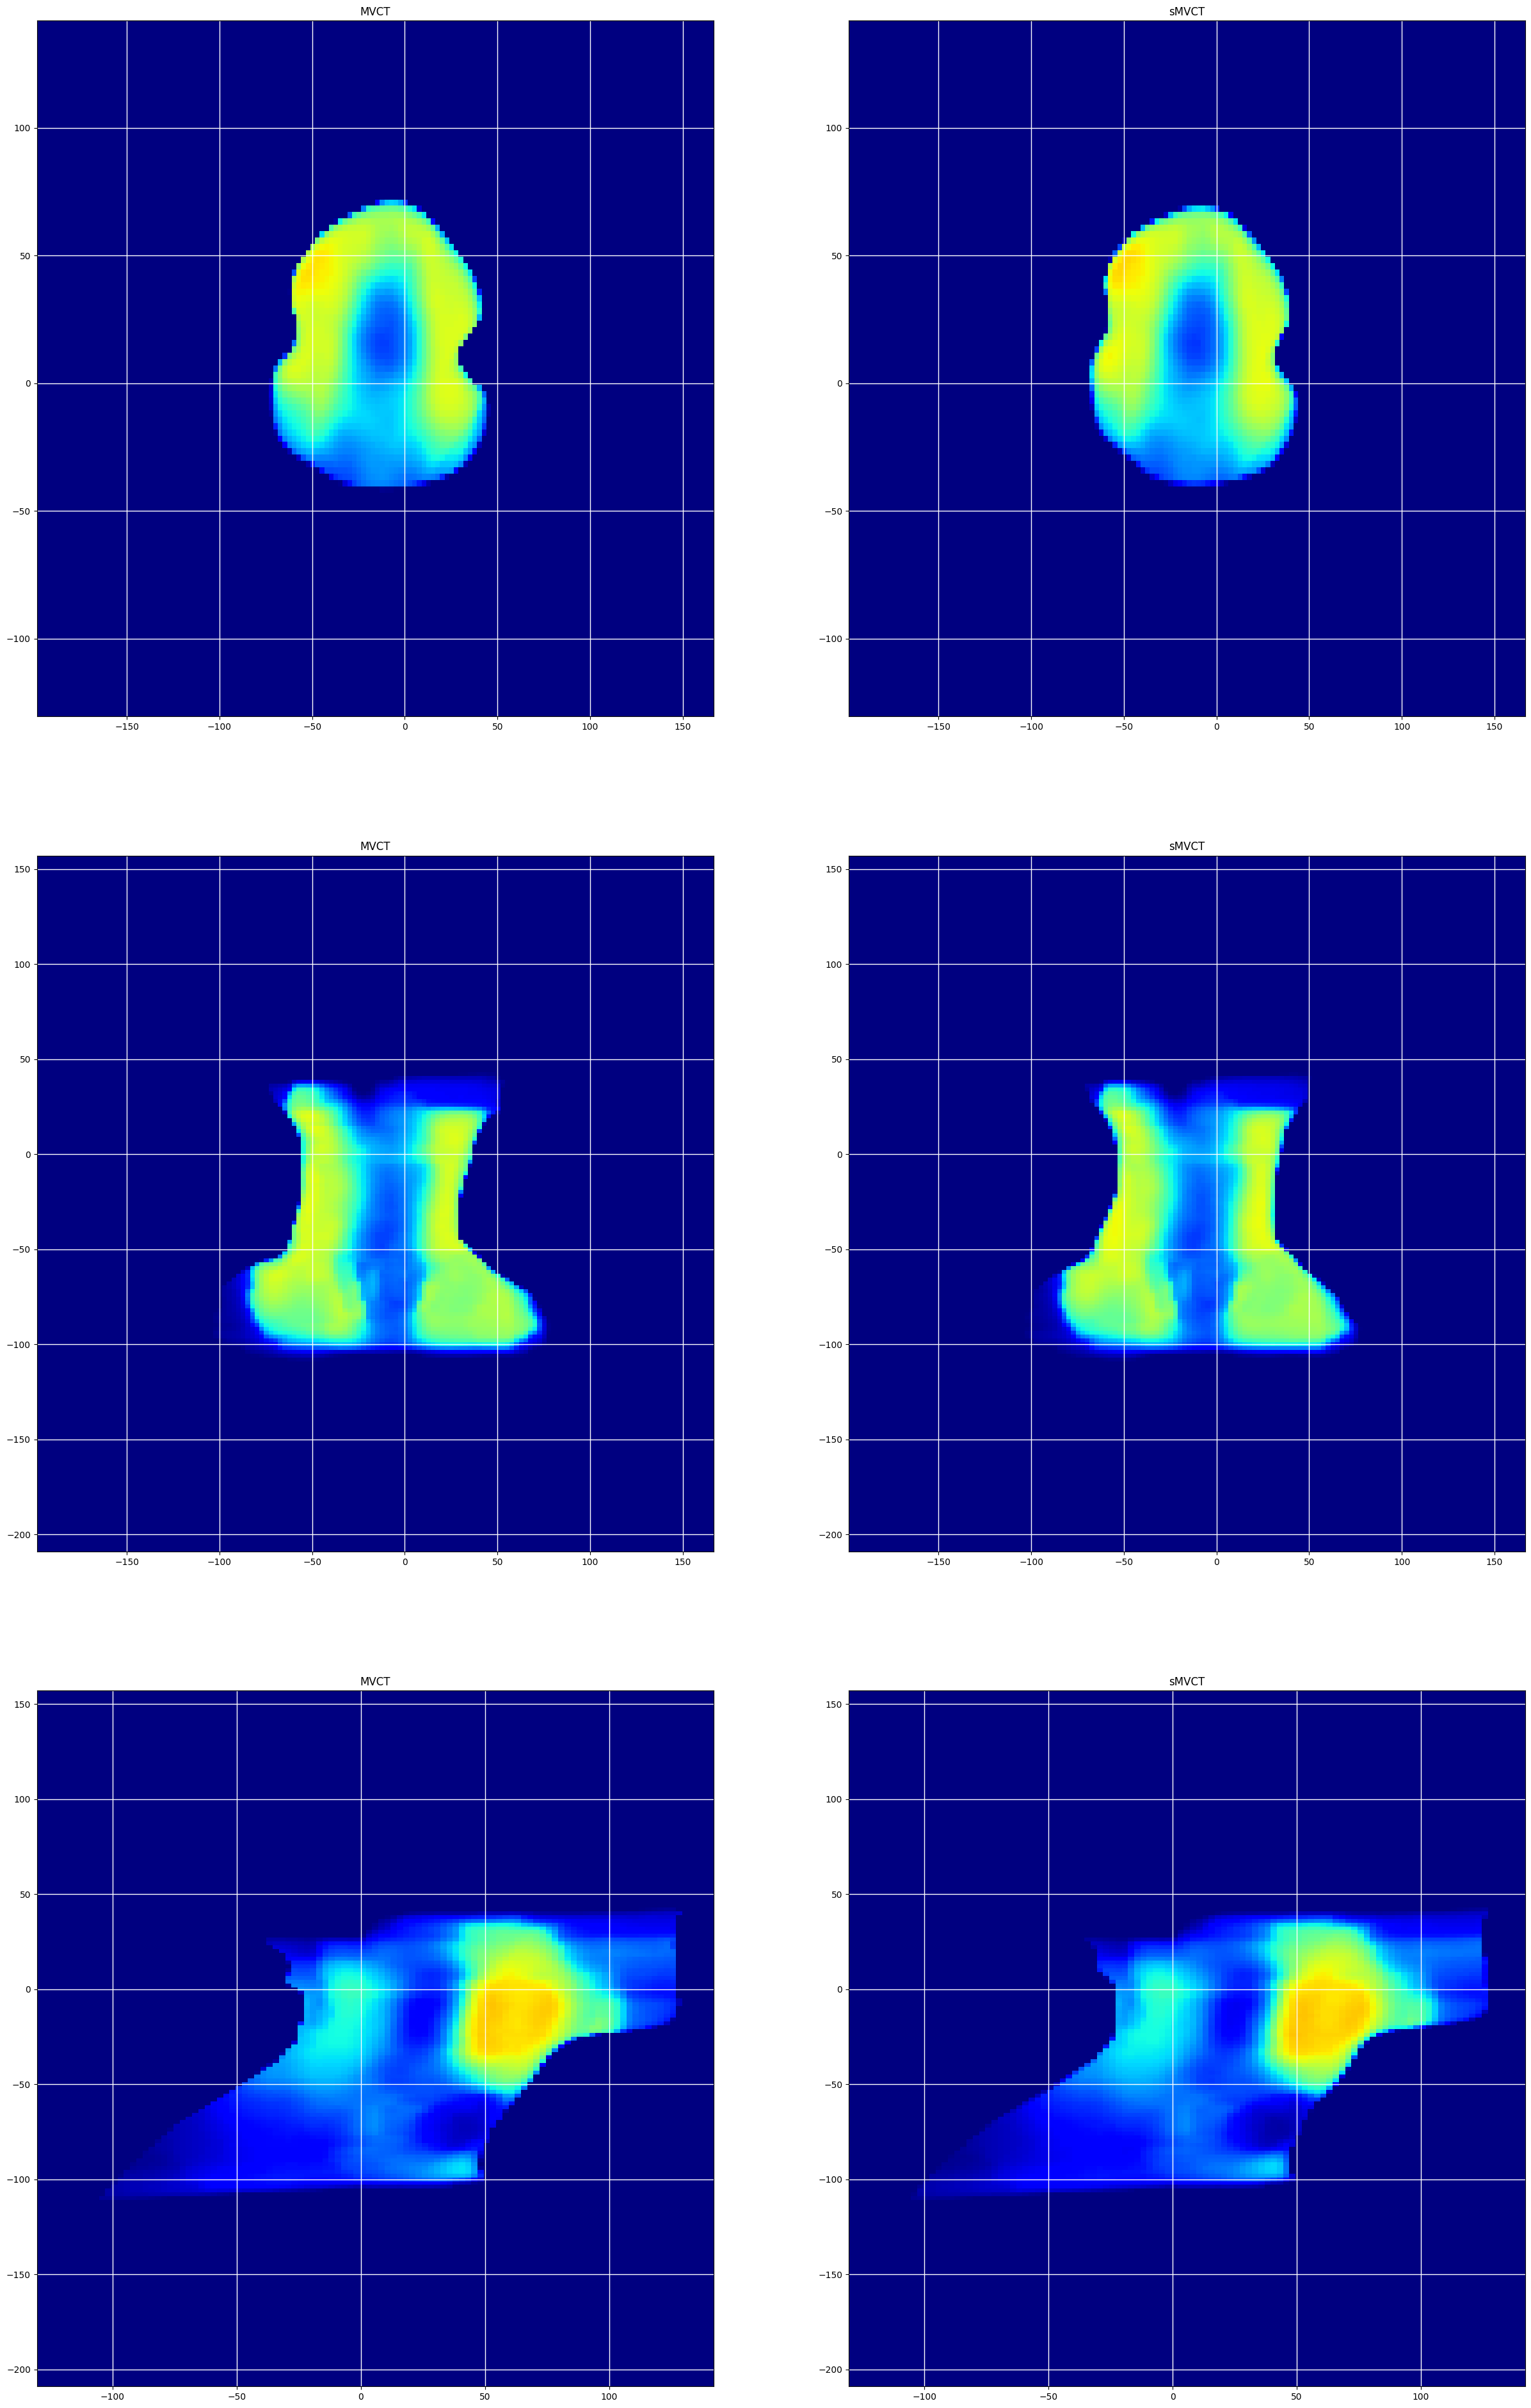

In [23]:
cent=(scipy.ndimage.center_of_mass(dose_reference))
x=x_dose_ref
y=y_dose_ref
z=z_dose_ref


fig, axs = plt.subplots(3, 2, figsize=(30, 48))
axs[0,0].pcolormesh(x,y,((dose_reference[math.floor(cent[0]), :,:])),cmap='jet',vmin=10,vmax=100);axs[0,0].set_title('MVCT');axs[0,0].grid(color='white', linestyle='-', linewidth=1);
axs[0,1].pcolormesh(x,y,((reshaped_jitted_trilint[math.floor(cent[0]), :,:])),cmap='jet',vmin=10,vmax=100);axs[0,1].set_title('sMVCT');axs[0,1].grid(color='white', linestyle='-', linewidth=1)
axs[1, 0].pcolormesh(x,z,((dose_reference[:,math.floor(cent[1]), :])),cmap='jet',vmin=10,vmax=100);axs[1, 0].set_title('MVCT');axs[1,0].grid(color='white', linestyle='-', linewidth=1)
axs[1, 1].pcolormesh(x,z,((reshaped_jitted_trilint[:,math.floor(cent[1]), :])),cmap='jet',vmin=10,vmax=100);axs[1, 1].set_title('sMVCT');axs[1,1].grid(color='white', linestyle='-', linewidth=1);
axs[2, 0].pcolormesh(y,z,((dose_reference[:,:,math.floor(cent[2])])),cmap='jet',vmin=10,vmax=100);axs[2, 0].set_title('MVCT');axs[2,0].grid(color='white', linestyle='-', linewidth=1)
axs[2, 1].pcolormesh(y,z,((reshaped_jitted_trilint[:,:,math.floor(cent[2])])),cmap='jet',vmin=10,vmax=100),axs[2, 1].set_title('sMVCT');axs[2,1].grid(color='white', linestyle='-', linewidth=1)
plt.show()

In [24]:
axes_evaluation=z_dose_eval, np.flip(y_dose_eval), x_dose_eval
axes_reference=z_dose_ref, np.flip(y_dose_ref), x_dose_ref
axes_gamamreference, none = pymedphys.dicom.zyx_and_dose_from_dataset(reference_dicom) #riprendiamo assi originari del dicom di riferimento perchè tanto le matrici ora hanno le stesse coordinate

#tolleranze ellissoide gamma index
dose_percent_threshold = 2;distance_mm_threshold = 2

gamma = pymedphys.gamma(axes_gamamreference, dose_reference,axes_gamamreference, reshaped_jitted_trilint,dose_percent_threshold, distance_mm_threshold,lower_percent_dose_cutoff=5,local_gamma=False)

Text(0.5, 1.0, 'Pass rate(γ<=1): 93.53461356892365%')

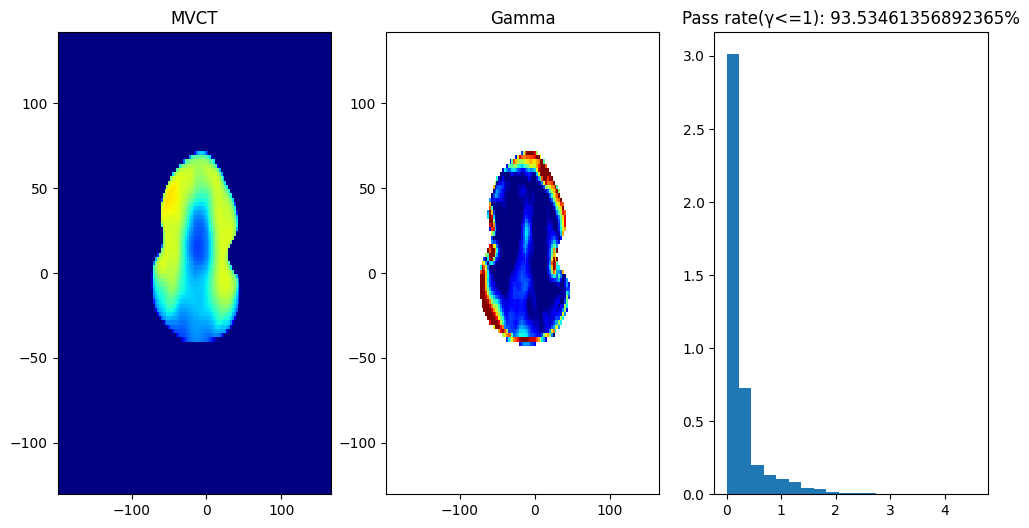

In [25]:
import matplotlib.pyplot as plt
# remove NaN grid points that were not evaluated as the dose value was below the dose threshold
valid_gamma = gamma[~np.isnan(gamma)]

fig, axs = plt.subplots(1, 3, figsize=(12, 6))
axs[0].pcolormesh(x,y,((dose_reference[math.floor(cent[0]), :,:])),cmap='jet',vmin=10,vmax=100);axs[0].set_title('MVCT')
axs[1].pcolormesh(x,y,((gamma[math.floor(cent[0]), :,:])),cmap='jet',vmin=0.1,vmax=1.2);axs[1].set_title('Gamma')

axs[2].hist(valid_gamma, bins=20, density=True), axs[2].set_title("gamma index density"),
axs[2].set_title(f"Pass rate(\u03B3<=1): {len(valid_gamma[valid_gamma <= 1]) / len(valid_gamma) * 100}%")

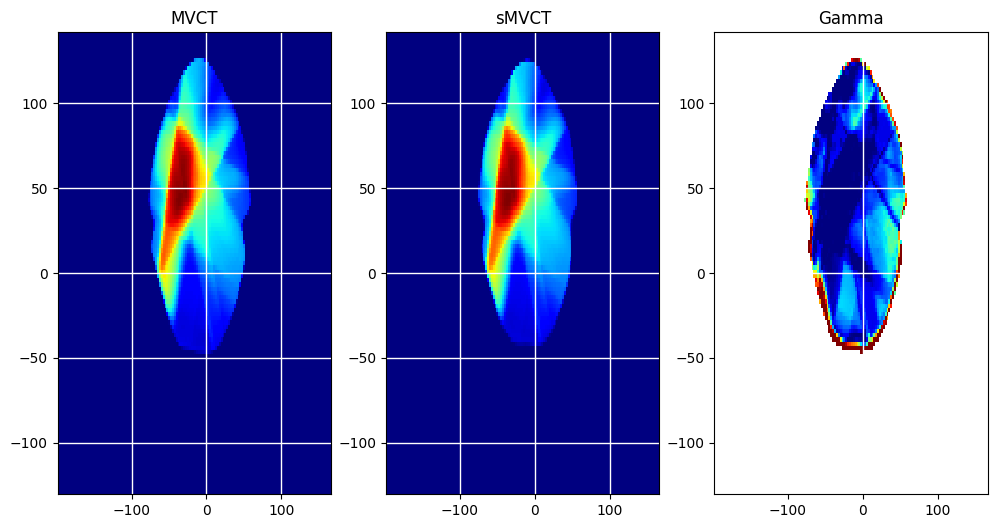

In [26]:
#aggiunta cris 11_4_25
fig, axs = plt.subplots(1, 3, figsize=(12, 6))
index_slice=100
index_slice=120

axs[0].pcolormesh(x,y,((dose_reference[index_slice, :,:])),cmap='jet');axs[0].set_title('MVCT')
axs[0].grid(color='white', linestyle='-', linewidth=1)
axs[1].pcolormesh(x,y,((reshaped_jitted_trilint[index_slice, :,:])),cmap='jet');axs[1].set_title('sMVCT')
axs[1].grid(color='white', linestyle='-', linewidth=1)
axs[2].pcolormesh(x,y,((gamma[index_slice, :,:])),cmap='jet',vmin=0.1,vmax=1.2);axs[2].set_title('Gamma')
axs[2].grid(color='white', linestyle='-', linewidth=1)
